# 227 — 학습 구간 확장·연도 표본 가중·기상 5열 검증

수치 원본은 같은 폴더의 `RESULTS.md`이고, 어긋나면 그쪽이 맞다. 이 노트북은 `compare.py`가 이미
`data/CROWD/interim/validation/masking_check/<창>/`에 남긴 `masking_check_*.parquet`을
**그림으로만** 다시 읽는다 — GPU도 재계산도 필요 없다.

`w2022`(2022~24 평탄 풀링)·`w2022w`(연도 표본 가중)의 표 W는 `compare.py --window w2022 / w2022w`가
백그라운드에서 도는 중이라 이 노트북을 만든 시점에 없을 수 있다 — 4·5절에서 존재 여부를 표로 남기고,
없는 창은 그림에서 건너뛴다.

| 축 | 값 |
| --- | --- |
| 시나리오(`scenario`) | `full` · `d7_only` · `d1_only` · `no_lag` |
| 슬라이스(`axis`) | `전체` · `호선`(1~8호선) · `요일유형`(평일·토요일·일요일·휴일) |
| 타깃(`target`) | `boarding`(승차) · `alighting`(하차) |
| 계열 | `lookup` · `lightgbm`(현행 배포) · `lgbm_masked_stack`(마스킹 LightGBM, 배포 레시피) · `lgbm_masked_weather`(기상 5열 후보) |
| 기상 비교(1~3절, 표 A·B) | 창 `w2024wx`, 기준 `w2024b_masked-stack` |
| 창 비교(4·5절, 표 W) | `w2024→w2024b`(축제 표 변경) · `w2024b→w2022`(평탄 풀링) · `w2024b→w2022w`(연도 가중) |

## 표 W 존재 여부 (빌드 시점)

| 비교 | 상태 |
| --- | --- |
| `w2024 → w2024b` | 있음 |
| `w2024b → w2022` | 있음 |
| `w2024b → w2022w` | 있음 |

In [1]:
import sys
from pathlib import Path

AI_ROOT = Path.cwd()
while not (AI_ROOT / "app" / "CROWD").exists():
    AI_ROOT = AI_ROOT.parent
sys.path.insert(0, str(AI_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from DATA_ENGINE.eda import figstyle

figstyle.apply(inline=True)

VAL_ROOT = AI_ROOT / "data" / "CROWD" / "interim" / "validation" / "masking_check"

WEATHER_WINDOW = "w2024wx"
W_COMPARISONS = [
    ("w2024", "w2024b"),
    ("w2024b", "w2022"),
    ("w2024b", "w2022w"),
]

TARGETS = ["boarding", "alighting"]
KOR = {"boarding": "승차", "alighting": "하차"}
SC_ORDER = ["full", "d7_only", "d1_only", "no_lag"]
DAY_ORDER = ["평일", "토요일", "일요일", "휴일"]
LINE_ORDER = [f"{n}호선" for n in range(1, 9)]
SERIES_W = ["lgbm_masked_stack", "lookup"]


def _read(window, name):
    p = VAL_ROOT / window / f"masking_check_{name}.parquet"
    return pd.read_parquet(p) if p.exists() else None


b_weather = _read(WEATHER_WINDOW, "B_lightgbm_쌍차이")
if b_weather is None:
    raise SystemExit(f"기상 표 B가 없다: {WEATHER_WINDOW} — compare.py를 먼저 실행할 것")

w_tables = {}
for _base, _other in W_COMPARISONS:
    _tbl = _read(_other, "W_창간_쌍차이")
    if _tbl is not None:
        w_tables[_other] = _tbl

w_present = list(w_tables)
w_missing = [other for _, other in W_COMPARISONS if other not in w_tables]
print(f"기상 표 B: {WEATHER_WINDOW} · 커밋 {b_weather['git_commit'].iloc[0]}")
print(f"창 비교 표 W: 있음 {w_present} · 아직 없음 {w_missing}")

기상 표 B: w2024wx · 커밋 388bb9b
창 비교 표 W: 있음 ['w2024b', 'w2022', 'w2022w'] · 아직 없음 []


## 1. 기상 5열 — 표 B 쌍 차이, 전체

`lgbm_masked_weather`(배포 세트 + 기상 5열) − `w2024b_masked-stack`(기준). 양수 = 기상이 낫다.

                    point_diff_RMSE_%p(계열-LightGBM)  point_diff_MAE_%p(계열-LightGBM)
scenario target                                                                    
full     alighting                            -0.63                           -1.75
         boarding                             -0.18                           -1.96
d7_only  alighting                            -0.03                           -1.33
         boarding                              0.11                           -1.20
d1_only  alighting                             0.60                           -0.65
         boarding                              0.38                           -0.65
no_lag   alighting                             1.96                            2.38
         boarding                              1.53                            2.80


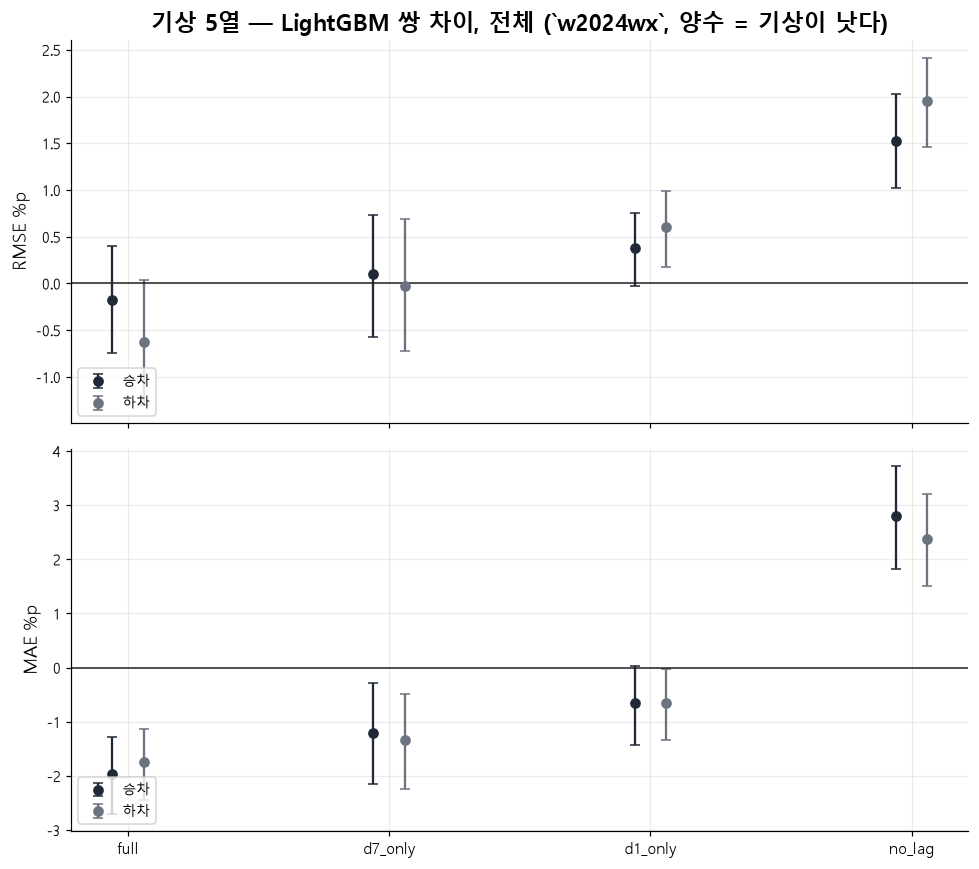

In [2]:
tot_b = b_weather[b_weather["axis"] == "전체"]
SC = sorted(tot_b["scenario"].unique(), key=SC_ORDER.index)
xx = np.arange(len(SC))

DIFF_RMSE = next(c for c in tot_b.columns if c.startswith("point_diff_RMSE_%p"))
DIFF_MAE = next(c for c in tot_b.columns if c.startswith("point_diff_MAE_%p"))

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
PANELS = [
    (axes[0], DIFF_RMSE, "diff_RMSE_CI_low", "diff_RMSE_CI_high", "RMSE %p"),
    (axes[1], DIFF_MAE, "diff_MAE_CI_low", "diff_MAE_CI_high", "MAE %p"),
]
for ax, col, lo_col, hi_col, ylabel in PANELS:
    for i, t in enumerate(TARGETS):
        sub = tot_b[tot_b["target"] == t].set_index("scenario").reindex(SC)
        point = sub[col].to_numpy()
        err = [point - sub[lo_col].to_numpy(), sub[hi_col].to_numpy() - point]
        ax.errorbar(xx + (i - 0.5) * 0.12, point, yerr=err, fmt="o", capsize=3,
                    label=KOR[t], color=figstyle.PALETTE_NEUTRAL[i])
    ax.axhline(0, color="#222", linewidth=1.0)
    ax.set_xticks(xx)
    ax.set_xticklabels(SC)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9, loc="lower left")
axes[0].set_title(f"기상 5열 — LightGBM 쌍 차이, 전체 (`{WEATHER_WINDOW}`, 양수 = 기상이 낫다)")
fig.tight_layout()
_ = figstyle.save(fig, f"weather_diff_overall_{WEATHER_WINDOW}")

print(tot_b.set_index(["scenario", "target"])[[DIFF_RMSE, DIFF_MAE]].round(2).to_string())

## 2. 기상 5열 — 요일유형 슬라이스 (`full`)

주말·평일에 기상 효과가 갈리는지를 본다(RESULTS.md 2.2절).

               point_diff_RMSE_%p(계열-LightGBM)
평일  boarding                             -1.03
    alighting                            -1.18
토요일 boarding                              1.37
    alighting                             0.52
일요일 boarding                              1.82
    alighting                             1.40
휴일  boarding                             -1.05
    alighting                            -2.02


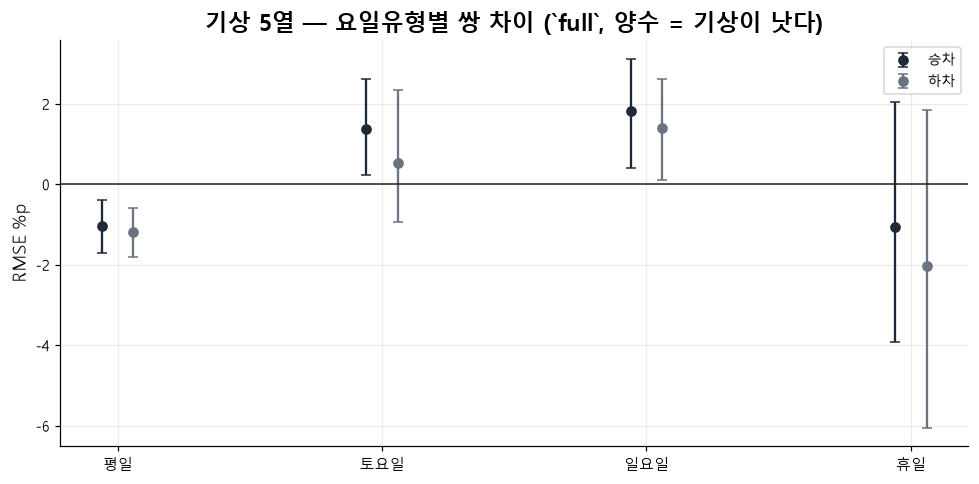

In [3]:
DIFF_RMSE = next(c for c in b_weather.columns if c.startswith("point_diff_RMSE_%p"))
day_b = b_weather[(b_weather["axis"] == "요일유형") & (b_weather["scenario"] == "full")]
DAYS = [d for d in DAY_ORDER if d in day_b["group"].unique()]
xx2 = np.arange(len(DAYS))

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, t in enumerate(TARGETS):
    sub = day_b[day_b["target"] == t].set_index("group").reindex(DAYS)
    point = sub[DIFF_RMSE].to_numpy()
    err = [point - sub["diff_RMSE_CI_low"].to_numpy(), sub["diff_RMSE_CI_high"].to_numpy() - point]
    ax.errorbar(xx2 + (i - 0.5) * 0.12, point, yerr=err, fmt="o", capsize=3,
                label=KOR[t], color=figstyle.PALETTE_NEUTRAL[i])
ax.axhline(0, color="#222", linewidth=1.0)
ax.set_xticks(xx2)
ax.set_xticklabels(DAYS)
ax.set_ylabel("RMSE %p")
ax.set_title("기상 5열 — 요일유형별 쌍 차이 (`full`, 양수 = 기상이 낫다)")
ax.legend(fontsize=9)
fig.tight_layout()
_ = figstyle.save(fig, f"weather_diff_daytype_full_{WEATHER_WINDOW}")

print(day_b.set_index(["group", "target"])[[DIFF_RMSE]].reindex(
    pd.MultiIndex.from_product([DAYS, TARGETS])
).round(2).to_string())

## 3. 기상 5열 — 호선 슬라이스 (`full` · `d7_only`)

어느 호선도 전체와 다른 모양을 보이는지 확인한다(2호선 전용 후속 개폐 기준, RESULTS.md 5절).

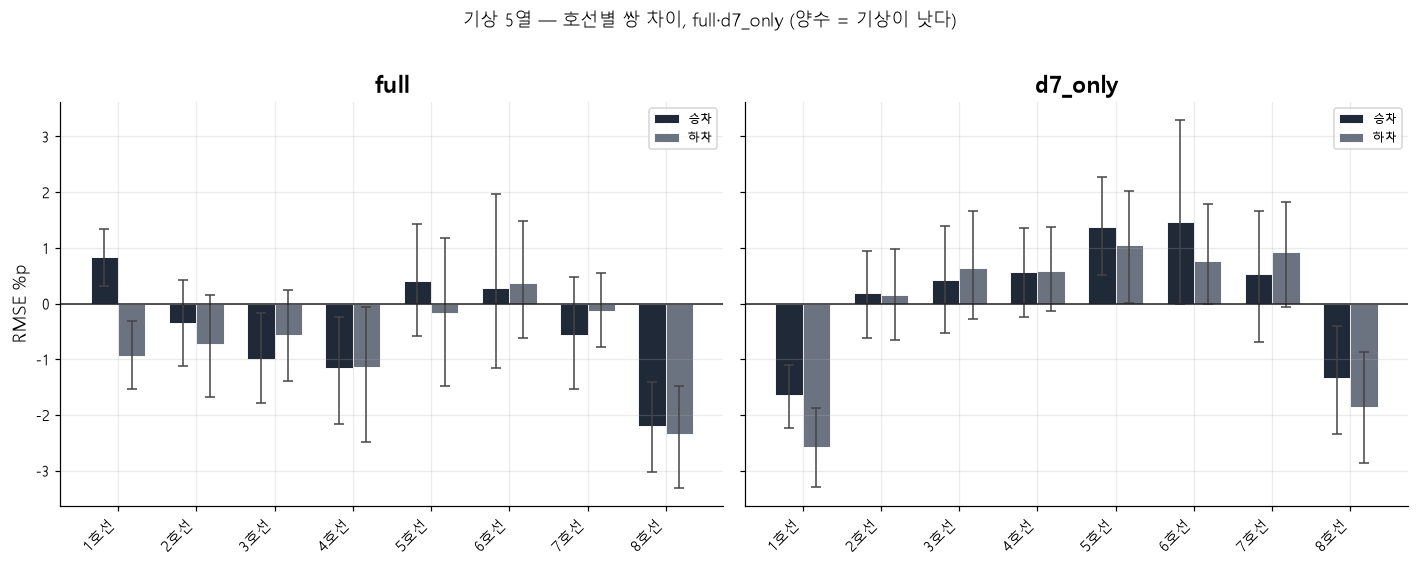

In [4]:
DIFF_RMSE = next(c for c in b_weather.columns if c.startswith("point_diff_RMSE_%p"))
LINE_SC = ["full", "d7_only"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
width = 0.35
for ax, sc in zip(axes, LINE_SC):
    sub_sc = b_weather[(b_weather["axis"] == "호선") & (b_weather["scenario"] == sc)]
    lines = [ln for ln in LINE_ORDER if ln in sub_sc["group"].unique()]
    xx3 = np.arange(len(lines))
    for i, t in enumerate(TARGETS):
        sub = sub_sc[sub_sc["target"] == t].set_index("group").reindex(lines)
        point = sub[DIFF_RMSE].to_numpy()
        err = [point - sub["diff_RMSE_CI_low"].to_numpy(),
               sub["diff_RMSE_CI_high"].to_numpy() - point]
        ax.bar(xx3 + (i - 0.5) * width, point, width, yerr=err, capsize=3, label=KOR[t],
               color=figstyle.PALETTE_NEUTRAL[i], edgecolor="white", linewidth=0.6,
               error_kw={"ecolor": "#444", "elinewidth": 1.0})
    ax.axhline(0, color="#222", linewidth=1.0)
    ax.set_xticks(xx3)
    ax.set_xticklabels(lines, rotation=45, ha="right")
    ax.set_title(sc)
    ax.legend(fontsize=8)
axes[0].set_ylabel("RMSE %p")
fig.suptitle("기상 5열 — 호선별 쌍 차이, full·d7_only (양수 = 기상이 낫다)", y=1.02)
fig.tight_layout()
_ = figstyle.save(fig, f"weather_diff_line_{WEATHER_WINDOW}")

## 4. 표 W — 창 비교, 전체 슬라이스

`lgbm_masked_stack`·`lookup`의 rel RMSE %(양수 = 뒤 창이 낫다)를 시나리오 4개로 본다. 위 표에서
"(아직 없음)"인 비교는 이 그림에서 빠진다.

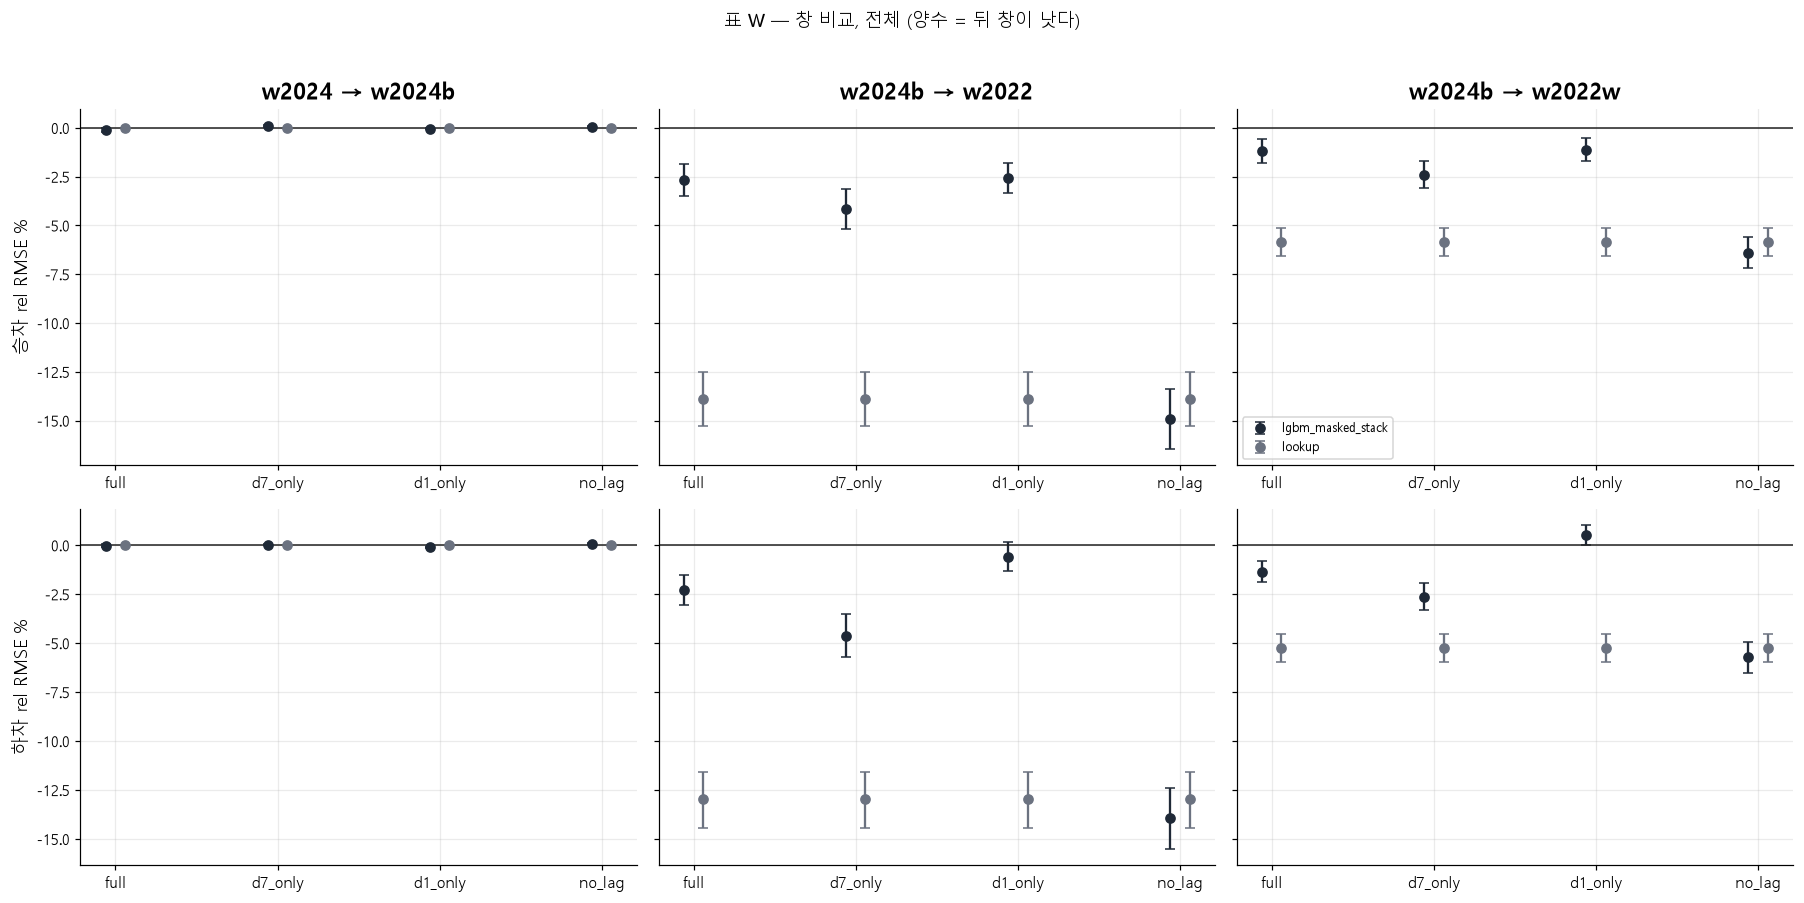

In [5]:
pairs = [(base, other) for base, other in W_COMPARISONS if other in w_tables]

if not pairs:
    print("표 W 없음 — compare.py --window w2022 / w2022w가 아직 안 끝났다")
else:
    fig, axes = plt.subplots(len(TARGETS), len(pairs), figsize=(5.5 * len(pairs), 8),
                              sharey="row", squeeze=False)
    for col, (base, other) in enumerate(pairs):
        tot_w = w_tables[other]
        tot_w = tot_w[tot_w["axis"] == "전체"]
        SCW = sorted(tot_w["scenario"].unique(), key=SC_ORDER.index)
        xxw = np.arange(len(SCW))
        for row, t in enumerate(TARGETS):
            ax = axes[row][col]
            for i, s in enumerate(SERIES_W):
                sub = tot_w[(tot_w["series"] == s) & (tot_w["target"] == t)]
                sub = sub.set_index("scenario").reindex(SCW)
                point = sub["rel_RMSE_%"].to_numpy()
                err = [point - sub["rel_RMSE_CI_low"].to_numpy(),
                       sub["rel_RMSE_CI_high"].to_numpy() - point]
                ax.errorbar(xxw + (i - 0.5) * 0.12, point, yerr=err, fmt="o", capsize=3,
                            label=s, color=figstyle.PALETTE_NEUTRAL[i])
            ax.axhline(0, color="#222", linewidth=1.0)
            ax.set_xticks(xxw)
            ax.set_xticklabels(SCW)
            if row == 0:
                ax.set_title(f"{base} → {other}")
            if col == 0:
                ax.set_ylabel(f"{KOR[t]} rel RMSE %")
            if row == 0 and col == len(pairs) - 1:
                ax.legend(fontsize=8)
    fig.suptitle("표 W — 창 비교, 전체 (양수 = 뒤 창이 낫다)", y=1.02)
    fig.tight_layout()
    _ = figstyle.save(fig, "window_diff_overall")

## 5. 표 W — 호선 슬라이스 (`full`)

있는 창 비교만 그린다.

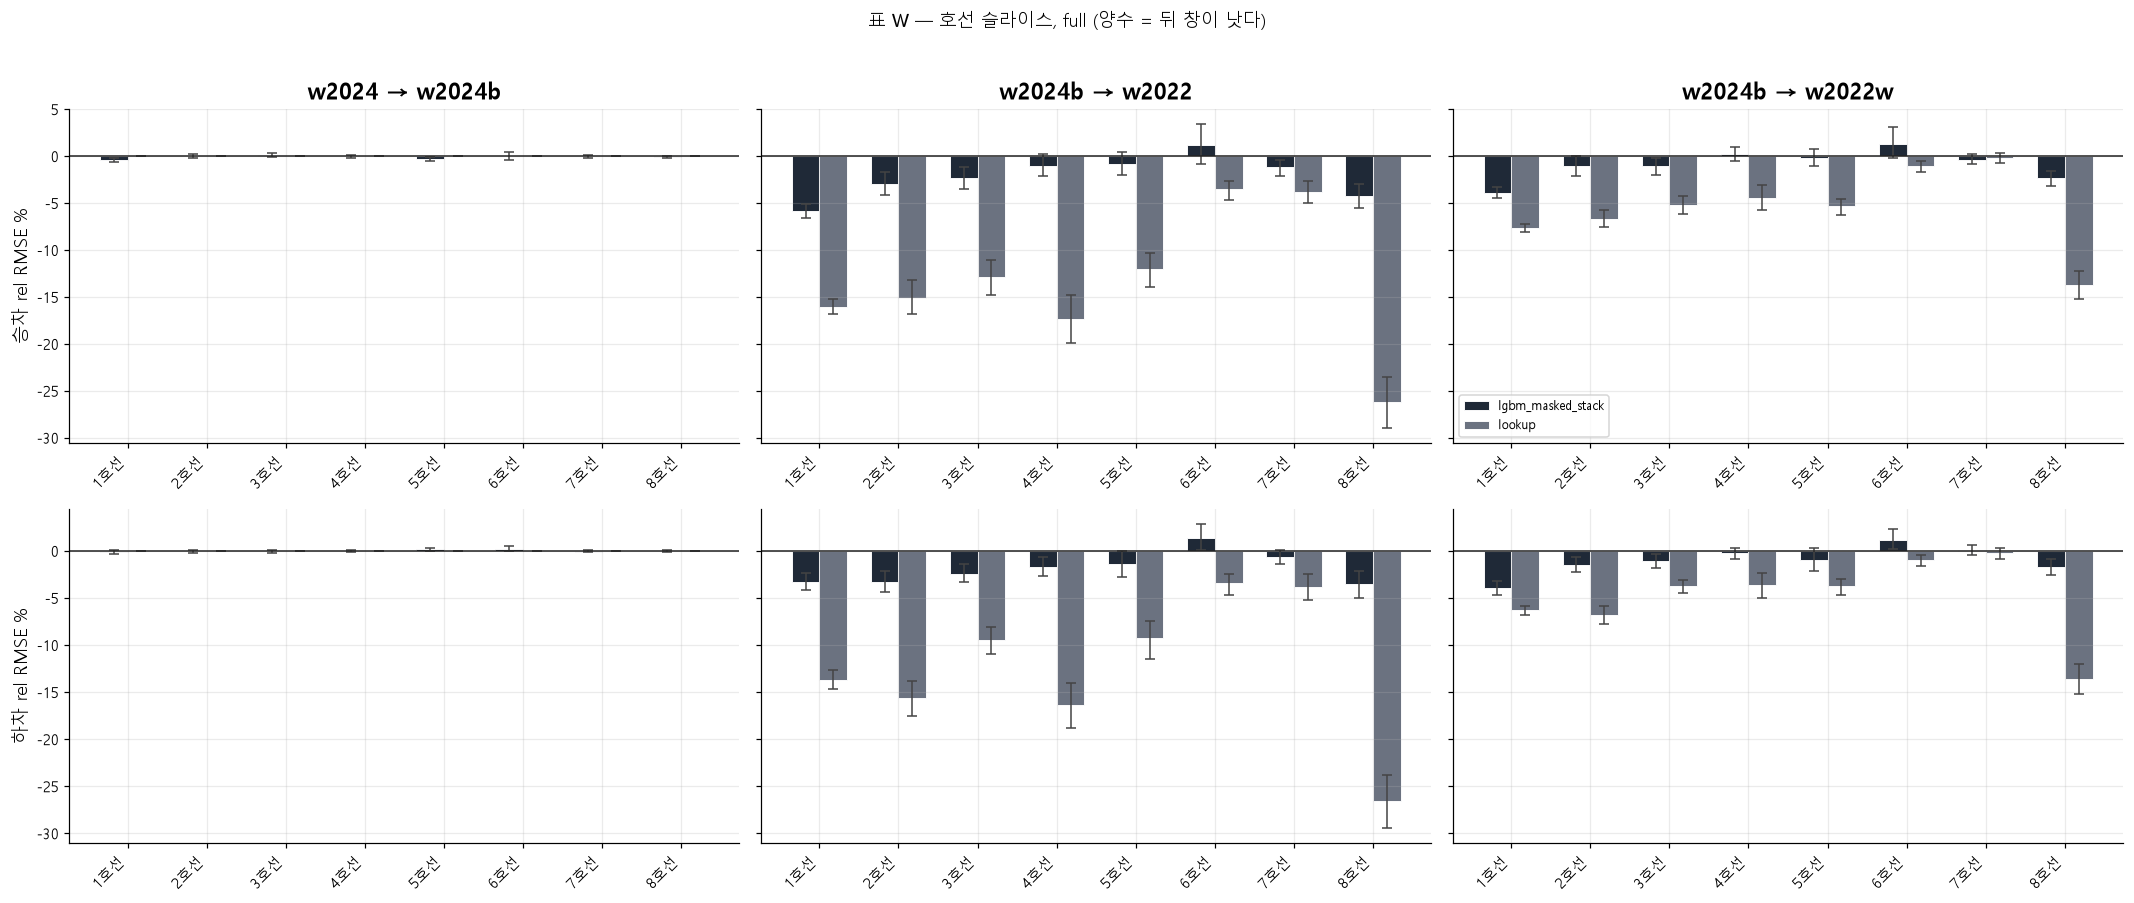

In [6]:
pairs = [(base, other) for base, other in W_COMPARISONS if other in w_tables]

if not pairs:
    print("표 W 없음 — compare.py --window w2022 / w2022w가 아직 안 끝났다")
else:
    fig, axes = plt.subplots(len(TARGETS), len(pairs), figsize=(6.5 * len(pairs), 8),
                              sharey="row", squeeze=False)
    width = 0.35
    for col, (base, other) in enumerate(pairs):
        tot_w = w_tables[other]
        line_w = tot_w[(tot_w["axis"] == "호선") & (tot_w["scenario"] == "full")]
        lines = [ln for ln in LINE_ORDER if ln in line_w["group"].unique()]
        xx5 = np.arange(len(lines))
        for row, t in enumerate(TARGETS):
            ax = axes[row][col]
            sub_t = line_w[line_w["target"] == t]
            for i, s in enumerate(SERIES_W):
                sub = sub_t[sub_t["series"] == s].set_index("group").reindex(lines)
                point = sub["rel_RMSE_%"].to_numpy()
                err = [point - sub["rel_RMSE_CI_low"].to_numpy(),
                       sub["rel_RMSE_CI_high"].to_numpy() - point]
                ax.bar(xx5 + (i - 0.5) * width, point, width, yerr=err, capsize=3, label=s,
                       color=figstyle.PALETTE_NEUTRAL[i], edgecolor="white", linewidth=0.6,
                       error_kw={"ecolor": "#444", "elinewidth": 1.0})
            ax.axhline(0, color="#222", linewidth=1.0)
            ax.set_xticks(xx5)
            ax.set_xticklabels(lines, rotation=45, ha="right")
            if row == 0:
                ax.set_title(f"{base} → {other}")
            if col == 0:
                ax.set_ylabel(f"{KOR[t]} rel RMSE %")
            if row == 0 and col == len(pairs) - 1:
                ax.legend(fontsize=8)
    fig.suptitle("표 W — 호선 슬라이스, full (양수 = 뒤 창이 낫다)", y=1.02)
    fig.tight_layout()
    _ = figstyle.save(fig, "window_diff_line_full")

## 6. 읽는 법

판정은 `RESULTS.md` 6절(H1 평탄 풀링·H2 연도 가중 채택·H3 기상 예비 채택 기준)을 따른다. 이 노트북은
그 판정에 쓰이는 표를 그림으로만 보여준다 — 수치가 어긋나면 `RESULTS.md`가 맞다.